In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

In [ ]:
df = pd.read_csv("train_and_test2.csv")
print(df.isnull().sum())


Passengerid    0
Age            0
Fare           0
Sex            0
sibsp          0
zero           0
zero.1         0
zero.2         0
zero.3         0
zero.4         0
zero.5         0
zero.6         0
Parch          0
zero.7         0
zero.8         0
zero.9         0
zero.10        0
zero.11        0
zero.12        0
zero.13        0
zero.14        0
Pclass         0
zero.15        0
zero.16        0
Embarked       2
zero.17        0
zero.18        0
2urvived       0
dtype: int64


In [14]:
df.info()

<class 'pandas.DataFrame'>
Index: 1307 entries, 0 to 1308
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Passengerid  1307 non-null   int64  
 1   Age          1307 non-null   float64
 2   Fare         1307 non-null   float64
 3   Sex          1307 non-null   int64  
 4   sibsp        1307 non-null   int64  
 5   Parch        1307 non-null   int64  
 6   Pclass       1307 non-null   int64  
 7   Embarked     1307 non-null   float64
 8   Survived     1307 non-null   int64  
dtypes: float64(3), int64(6)
memory usage: 102.1 KB


In [4]:
df = df.drop(columns=[col for col in df.columns if "zero" in col or "Unnamed" in col])
df = df.dropna(subset=["Embarked"])
df = df.rename(columns={'2urvived':'Survived'})
print(df.isnull().sum())

Passengerid    0
Age            0
Fare           0
Sex            0
sibsp          0
Parch          0
Pclass         0
Embarked       0
Survived       0
dtype: int64


In [12]:
mean_age = np.mean(df['Age'])
median_age = np.median(df['Age'])
mode_age = stats.mode(df['Age'])
mean_age


np.float64(29.471820964039786)

In [13]:
median_age
mode_age

ModeResult(mode=np.float64(28.0), count=np.int64(295))

In [17]:
df['Age'].value_counts()

Age
28.00    295
24.00     47
22.00     43
21.00     41
30.00     40
        ... 
60.50      1
11.50      1
0.33       1
0.17       1
38.50      1
Name: count, Length: 98, dtype: int64

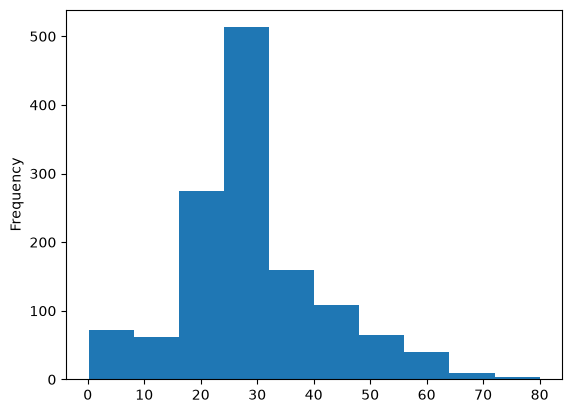

In [19]:
df['Age'].plot(kind ='hist',bins =10)
plt.show()

the data is right skewed as we can see because the value spread upto 80 while mean mean and median is 29.odd and 28 respectively which is also an indicator where mean is greater than median means right skewed 

In [24]:
population_variance = np.var(df['Age'])
population_std = np.std(df['Age'])

population_variance,population_std

(np.float64(165.80844855861176), np.float64(12.876662943426444))

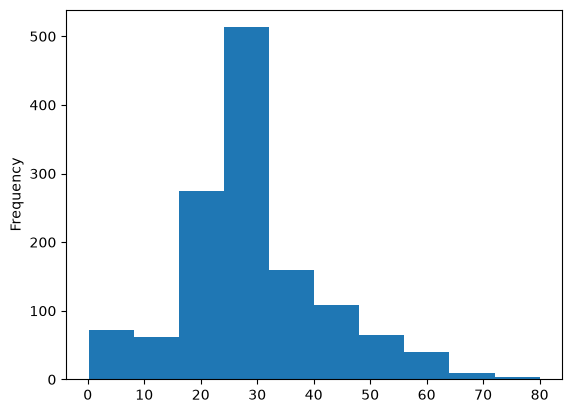

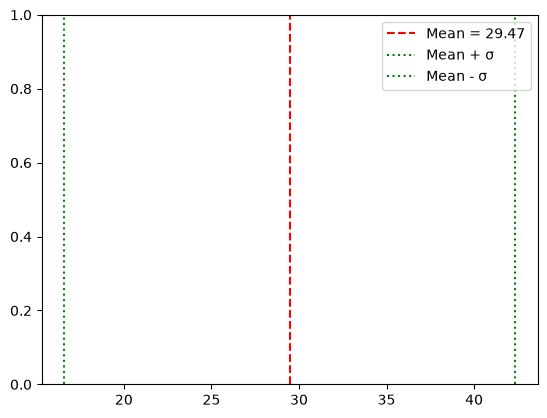

In [27]:
df['Age'].plot(kind ='hist',bins =10)
plt.show()
plt.axvline(mean_age, color="red", linestyle="--", label=f"Mean = {mean_age:.2f}")

# Add variance as spread (mean ± sqrt(var))
plt.axvline(mean_age + population_variance**0.5, color="green", linestyle=":", label="Mean + σ")
plt.axvline(mean_age - population_variance**0.5, color="green", linestyle=":", label="Mean - σ")

plt.legend()
plt.show()

In [28]:
df.groupby("Survived")["Age"].mean()

Survived
0    29.931748
1    28.163735
Name: Age, dtype: float64

<Axes: >

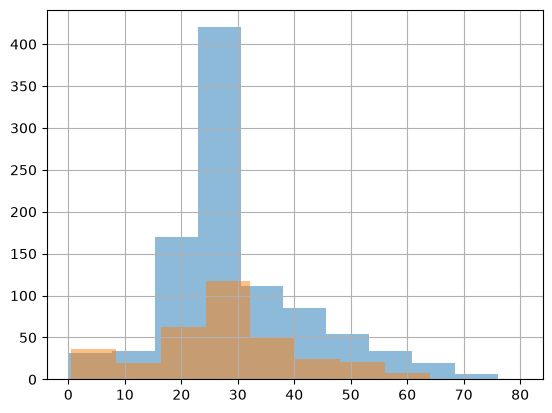

In [29]:
df[df["Survived"]==0]["Age"].hist(alpha=0.5, label="Not Survived")
df[df["Survived"]==1]["Age"].hist(alpha=0.5, label="Survived")